In [2]:
import sys
from pathlib import Path

# Project root
PROJECT_ROOT = Path("..").resolve()

# Make src importable
sys.path.append(str(PROJECT_ROOT))

# Data paths
RAW_DATA = PROJECT_ROOT / "data" / "raw"
SCORES_PATH = PROJECT_ROOT / "data" / "scores.csv"


In [3]:
from pathlib import Path
from src.utils import load_all_subjects, load_scores

df = load_all_subjects(RAW_DATA)
scores = load_scores(SCORES_PATH)

print("Total subjects:", df["participant_id"].nunique())
print(df.groupby("group")["participant_id"].nunique())

print("\nFirst rows:")
df.head()


Total subjects: 55
group
condition    23
control      32
Name: participant_id, dtype: int64

First rows:


,timestamp,activity,participant_id,group
0,2003-05-07 12:00:00,0,condition_1,condition
1,2003-05-07 12:01:00,143,condition_1,condition
2,2003-05-07 12:02:00,0,condition_1,condition
3,2003-05-07 12:03:00,20,condition_1,condition
4,2003-05-07 12:04:00,166,condition_1,condition


In [4]:
from src.windowing import add_day_column, get_unique_days

# Pick one subject to inspect
pid = df["participant_id"].iloc[0]
df_one = df[df["participant_id"] == pid]

df_one = add_day_column(df_one)
days = get_unique_days(df_one)

print("Participant:", pid)
print("Number of unique days:", len(days))
print("First 5 days:")
print(days.head())

# Check minutes per day
counts = df_one.groupby("day")["timestamp"].count()
print("\nMinutes per day (first 5):")
print(counts.head())

Participant: condition_1
Number of unique days: 17
First 5 days:
0   2003-05-07
1   2003-05-08
2   2003-05-09
3   2003-05-10
4   2003-05-11
dtype: datetime64[us]

Minutes per day (first 5):
day
2003-05-07     720
2003-05-08    1440
2003-05-09    1440
2003-05-10    1440
2003-05-11    1440
Name: timestamp, dtype: int64


In [5]:
from src.windowing import daily_minute_counts, is_day_complete

counts = daily_minute_counts(df_one)

print("Daily minute counts (first 5):")
print(counts.head())

print("\nCompleteness check (first 5 days):")
for day, count in counts.head().items():
    print(day.date(), count, "complete?" , is_day_complete(count))

Daily minute counts (first 5):
day
2003-05-07     720
2003-05-08    1440
2003-05-09    1440
2003-05-10    1440
2003-05-11    1440
Name: timestamp, dtype: int64

Completeness check (first 5 days):
2003-05-07 720 complete? False
2003-05-08 1440 complete? True
2003-05-09 1440 complete? True
2003-05-10 1440 complete? True
2003-05-11 1440 complete? True


In [5]:
# -------------------------------
# Naive baseline: shuffle within a valid day
# -------------------------------

df_one = add_day_column(df_one)

counts = daily_minute_counts(df_one)

complete_days = [
    day for day, count in counts.items()
    if is_day_complete(count)
]

day = complete_days[0]

df_day = (
    df_one[df_one["day"] == day]
    .sort_values("timestamp")
)

# Apply the naive baseline
from src.baselines import shuffle_within_window

df_day_shuffled = shuffle_within_window(
    df_day,
    activity_col="activity",
    random_state=42
)

import numpy as np

# Sanity checks
assert np.all(
    np.sort(df_day["activity"].values)
    ==
    np.sort(df_day_shuffled["activity"].values)
)

assert not np.all(
    df_day["activity"].values
    ==
    df_day_shuffled["activity"].values
)

print("Naive baseline sanity check passed ✔")


Naive baseline sanity check passed ✔


In [ ]:
# -------------------------------
# Naive Baseline: Cosinor (Parametric) Baseline - Manual Reconstruction
# -------------------------------
import numpy as np
import pandas as pd
from src.windowing import add_day_column, daily_minute_counts, is_day_complete
from src.baselines import fit_cosinor

# 1. Prepare data
df_one = add_day_column(df_one)
counts = daily_minute_counts(df_one)
complete_days = [day for day, count in counts.items() if is_day_complete(count)]
day = complete_days[0]
df_day = df_one[df_one["day"] == day].sort_values("timestamp").copy()

# 2. Run the model (returns a dictionary of floats)
results_dict = fit_cosinor(df_day, activity_col="activity")

# 3. Extract parameters (Adjust keys if your dict uses different names)
M = results_dict.get('mesor')
A = results_dict.get('amplitude') or results_dict.get('amp')
phi = results_dict.get('acrophase') or results_dict.get('phase')

# 4. RECONSTRUCT the fit (The "Missing" Step)
# 1440 minutes in a day; t is the minute of the day (0 to 1439)
t = np.arange(len(df_day))
df_day['cosinor_fit'] = M + A * np.cos(2 * np.pi * t / 1440 + phi)

# 5. Formal Sanity Checks
assert "cosinor_fit" in df_day.columns
assert A >= 0
# Check that the fit has variance (it's a wave, not a flat line)
assert np.var(df_day['cosinor_fit']) > 0 

print(f"Cosinor Sanity Check passed ✔")
print(f"Parameters -> Mesor: {M:.2f}, Amp: {A:.2f}, Phase: {phi:.2f}")

Cosinor Sanity Check passed ✔
Parameters -> Mesor: 2.93, Amp: 2.47, Phase: 8.76


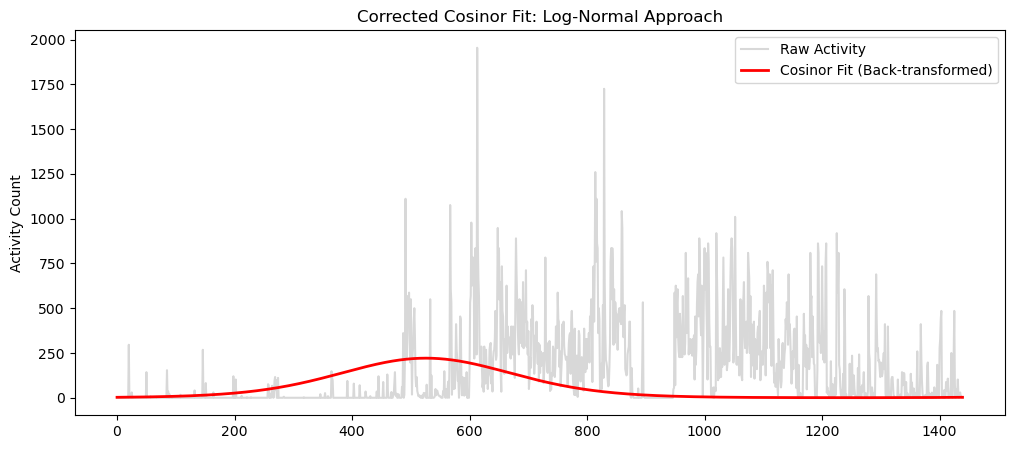

In [16]:
import matplotlib.pyplot as plt

# 1. Extract params from your results_dict
M = results_dict['mesor']
A = results_dict['amplitude']
phi_hours = results_dict['acrophase']

# 2. Reconstruct the fit in LOG-SPACE first
# We use hours (t) because your function uses: t = hours + minutes/60
t_hours = df_day["timestamp"].dt.hour + df_day["timestamp"].dt.minute / 60.0
phi_rad = (phi_hours * 2*np.pi) / 24 # Convert hours back to radians for np.cos

log_fit = M + A * np.cos(2 * np.pi * t_hours / 24 - phi_rad)

# 3. TRANSFORM BACK to raw scale (Inverse Log)
df_day['cosinor_fit_raw'] = np.expm1(log_fit)

# 4. Plot again
plt.figure(figsize=(12, 5))
plt.plot(range(len(df_day)), df_day['activity'], label='Raw Activity', color='gray', alpha=0.3)
plt.plot(range(len(df_day)), df_day['cosinor_fit_raw'], label='Cosinor Fit (Back-transformed)', color='red', linewidth=2)
plt.title(f"Corrected Cosinor Fit: Log-Normal Approach")
plt.ylabel("Activity Count")
plt.legend()
plt.show()    